In [142]:
import lightgbm
import pandas as pd
import numpy as np
import glob
import random

df_files = glob.glob("data/output_XSBench_1GB.txt")
workload = "XSBench_1GB"

dfs = []
for f in df_files:

    df_local = pd.read_csv(f, on_bad_lines="warn", nrows=50_000_000)
    if(len(df_local.index) > 10_000_000):
        df_local = df_local.sample(10_000_000)
    df_local["source"] = f
    
    print(len(df_local))
    
    if len(df_local) < 100000:
        print("Skipping small file:", f)
        continue
    
    #print(f"{f[:-4]}.sampled.txt")
    #df_local.to_csv(f"{f[:-4]}.sampled.txt", index=False)
    
    dfs.append(df_local)

source_lens = [len(df) for df in dfs]

min_length = min(source_lens)
print("Min length:", min_length)

total_samples = sum(source_lens)
print("Total samples:", total_samples)


train_df = pd.concat([df.assign(weight=min_length / len(df)) for df in dfs])


targets = ["target_width_10", "target_width_1", "target_width_2", "target_width_3", "target_width_4", "target_width_5",
           "target_width_25", "target_width_50", "target_width_100", 'discounted_reward_0.99',
           'discounted_reward_0.95', 'discounted_reward_0.90',
           'discounted_reward_0.75', 'discounted_reward_0.50']



3489361
Min length: 3489361
Total samples: 3489361


import seaborn as sns

import matplotlib.pyplot as plt

df_heat = train_df[train_df["step"] < 200]
pivot = df_heat.pivot_table(index="page", columns="step", values="discounted_reward_0.90")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="viridis", vmin=0, vmax=50)
plt.title("Heatmap of count (intensity) for /cc_out.txt")
plt.xlabel("step")
plt.ylabel("page")
plt.tight_layout()
plt.show()

In [143]:
train_df = train_df.merge((train_df.groupby("source")["step"].max() * .7).reset_index(), on=["source"], how="left", suffixes=("", "_split"))

In [144]:
#shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [145]:
#sampled_train_df = train_df.groupby("source", group_keys=False).apply(lambda x: x.sample(n=min_length, random_state=42))

In [146]:
#train_df["avg_reads"] = train_df["cumsum_reads"] / (train_df["age"] + 1)
#train_df["avg_writes"] = train_df["cumsum_writes"] / (train_df["age"] + 1)
#train_df["slope1"] = (train_df["avg_reads"] + 3 * train_df["avg_writes"]) / (train_df["ewma_5"] + 1)

In [147]:
#train_df["diff1"] = (train_df["avg_reads"] + 3 * train_df["avg_writes"]) - (train_df["ewma_5"] + 1)
#train_df["slope2"] = train_df["avg_reads"] / train_df["avg_writes"]
#train_df["slope3"] = train_df["ewma_5_r"] -  train_df["ewma_5_w"]
#train_df["slope4"] = train_df["ewma_5_r"] / (train_df["ewma_5_w"] + train_df["ewma_5_r"])
#train_df["slope6"] = train_df["ewma_5"] / (train_df["group_0_mean"])

import seaborn as sns

import matplotlib.pyplot as plt

df_heat = df_out[df_out["source"] == "pr_out.txt"]
#pivot = df_heat.pivot_table(index="page", columns="step", values="predicted_target", fill_value=0)

#plt.figure(figsize=(12, 8))
#sns.heatmap(pivot, cmap="viridis", vmax=5, vmin=0)
#plt.title("Heatmap of count (intensity) for cc_out.txt")
#plt.xlabel("step")
#plt.ylabel("page")
#plt.tight_layout()
#plt.show()

df_heat.plot(x="step", y="count_total", kind="scatter", alpha=0.1)

In [148]:
train_df.dropna(axis=0, inplace=True)

In [149]:
for col in train_df.columns:
    if col != "source" and col != "page" and col != "step":
        train_df[col] = train_df[col].astype("float64")
        #sampled_train_df[col] = sampled_train_df[col].astype("float64")

In [150]:
list(train_df.columns)

['step',
 'page',
 'read',
 'write',
 'count',
 'malloc_size',
 'ewma_2',
 'ewma_5',
 'ewma_20',
 'ewma_100',
 'ewma_2_r',
 'ewma_5_r',
 'ewma_20_r',
 'ewma_100_r',
 'ewma_2_w',
 'ewma_5_w',
 'ewma_20_w',
 'ewma_100_w',
 'ewma_2_perc',
 'ewma_5_perc',
 'ewma_20_perc',
 'ewma_100_perc',
 'ewma_2_r_perc',
 'ewma_5_r_perc',
 'ewma_20_r_perc',
 'ewma_100_r_perc',
 'ewma_2_w_perc',
 'ewma_5_w_perc',
 'ewma_20_w_perc',
 'ewma_100_w_perc',
 'ewma_2_malloc_size',
 'ewma_5_malloc_size',
 'ewma_20_malloc_size',
 'ewma_100_malloc_size',
 'ewma_2_malloc_calls',
 'ewma_5_malloc_calls',
 'ewma_20_malloc_calls',
 'ewma_100_malloc_calls',
 'global_count_since_top1_percent_ewma5',
 'global_count_since_top50_percent_ewma5',
 'rank',
 'rank_perc',
 'rank_ewma_2',
 'rank_ewma_5',
 'rank_ewma_20',
 'rank_ewma_100',
 'count_total',
 'global_count_similar',
 'diff',
 'cpu_usage',
 'disk_read_bytes',
 'disk_write_bytes',
 'syscr',
 'syscw',
 'age',
 'age_count_total',
 'group_-7_mean',
 'group_-7_mean_perc',


In [151]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

local_train_df = train_df

features = [ #"read", "write", "count",
    "ewma_2_perc",
    "ewma_5_perc", "ewma_20_perc", 
    "ewma_100_perc",
    #"ewma_2_r", 'ewma_5_r', 'ewma_20_r', 'ewma_100_r',
    #"ewma_2_w_perc",
    #'ewma_5_w_perc', 'ewma_20_w_perc',
    #'ewma_100_w_perc',
    #'global_count_since_top50_percent_ewma5', #'global_count_since_top1_percent_ewma5',
    #'rank',
    #'count_total', #'global_count_similar',
    #'diff',
    'group_-1_mean_perc', 'group_1_mean_perc',
    'group_-2_mean_perc', 'group_2_mean_perc',
    'group_-3_mean_perc', 'group_3_mean_perc',
    #'group_-4_mean_perc', 'group_4_mean_perc',
    #'group_-5_mean_perc', 'group_5_mean_perc',
    'group_0_mean_perc',
    #'slope1', 'avg_reads', 'avg_writes', "diff",
    #"slope2", "slope3", "slope4", "slope5", "slope6",
    "age_count_total",
    #'cpu_usage', #'disk_read_bytes', 'disk_write_bytes', 'syscr', 'syscw',
    #'prot_read', 'prot_write', 'prot_exec', 'prot_none',
    #'prot_growdown', 'prot_growsup', 'flags_shared',
    #'flags_shared_validate', 'flags_32bit',
    #'flags_anonymous', 'flags_fixed', 'flags_fixed_noreplace',
    #'flags_growdown', 'flags_hugetlb', 'flags_locked', 'flags_nonblock',
    #'flags_noreserve', 'flags_populate', 'flags_stack', 'flags_sync',
    #'read_syscalls', 'write_syscalls', 'read_bytes', 'write_bytes',
    #"malloc_call", "sum_malloc_bytes",
    #'ewma_2_malloc_size', 'ewma_5_malloc_size', 'ewma_20_malloc_size',
    #'ewma_100_malloc_size', 
    #'ewma_2_malloc_calls', 'ewma_5_malloc_calls', 'ewma_20_malloc_calls', 
    'ewma_100_malloc_calls',
    #'min_malloc_bytes', 'max_malloc_bytes',
]

for col in features:
    if "scaled_" in col:
        local_train_df[col] = (local_train_df[col[7:]] / local_train_df["count_total"]).replace([np.inf, -np.inf], 0)


targets = ["target_width_10", "target_width_1", "target_width_2", "target_width_3", "target_width_4", "target_width_5",
           "target_width_25", "target_width_50", "target_width_100"]

#local_train_df["discounted_reward_0.99_scaled"] = (local_train_df["discounted_reward_0.99"] / local_train_df["count_total"]).replace([np.inf, -np.inf], 0)
objective_col = "discounted_reward_0.99"
alpha = .75



X = local_train_df[features]
W = local_train_df["weight"]
y = local_train_df[objective_col].clip(lower=0).fillna(0)

X_train = X[local_train_df["step"] < local_train_df["step_split"]]
X_test = X[local_train_df["step"] >= local_train_df["step_split"]]
W_train = W[local_train_df["step"] < local_train_df["step_split"]]
W_test = W[local_train_df["step"] >= local_train_df["step_split"]]
y_train = y[local_train_df["step"] < local_train_df["step_split"]]
y_test = y[local_train_df["step"] >= local_train_df["step_split"]]

data = lightgbm.Dataset(X_train, label=y_train, weight=W_train)

model = lightgbm.train(
    params={
        'objective': "regression",
        'metric': 'l2',
        'verbosity': -1,
        'boosting_type': 'dart',
        "alpha": alpha,
        #"l1_regularization": 1000,
        #"l2_regularization": 1000,
        #"feature_fraction": 0.5,
        "learning_rate": 0.25,
        "max_bin": 8095,
        "max_depth": 6,
        #"min_data_in_leaf": 800,
        #"min_gain_to_split": 100,
        "num_iterations": 50,
        "num_leaves": 25,
        #"path_smooth": 1000,
        #"reg_sqrt": True,
    },
    train_set=data,
)


# Predict using the trained model
y_pred = model.predict(X_test)

print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

group_metrics = []

# Pivot the dataframe for heatmap
test_df = local_train_df[local_train_df["step"] >= local_train_df["step_split"]].copy()

df_out = test_df.copy()
df_out['predicted_target'] = model.predict(test_df[features])

for src, group in df_out.groupby("source"):
    y_true_group = group[objective_col].clip(lower=0).fillna(0)
    y_pred_group = group["predicted_target"].clip(lower=0).fillna(0)
    mae = mean_absolute_error(y_true_group, y_pred_group)
    rmse = root_mean_squared_error(y_true_group, y_pred_group)
    r2 = r2_score(y_true_group, y_pred_group)
    group_metrics.append({"source": src, "MAE": mae, "RMSE": rmse, "R2": r2})
    
metrics_df = pd.DataFrame(group_metrics)
print(metrics_df)


sorted(zip(model.feature_importance(), model.feature_importance(importance_type="gain"), model.feature_name()), key=lambda x: x[1], reverse=True)

Test RMSE: 325.7868
Test MAE: 41.5214
R^2: 0.8187
                        source        MAE        RMSE        R2
0  data/output_XSBench_1GB.txt  41.520112  325.786717  0.818726


[(np.int32(146), np.float64(9380050699808.0), 'ewma_5_perc'),
 (np.int32(156), np.float64(375517157582.0), 'ewma_100_malloc_calls'),
 (np.int32(314), np.float64(327009719298.0), 'age_count_total'),
 (np.int32(46), np.float64(141000922582.0), 'group_0_mean_perc'),
 (np.int32(101), np.float64(54433410248.0), 'ewma_20_perc'),
 (np.int32(165), np.float64(42963500754.0), 'ewma_100_perc'),
 (np.int32(37), np.float64(31269323462.0), 'group_1_mean_perc'),
 (np.int32(44), np.float64(19419963460.0), 'group_-1_mean_perc'),
 (np.int32(72), np.float64(16060917212.0), 'ewma_2_perc'),
 (np.int32(31), np.float64(12082571640.0), 'group_-3_mean_perc'),
 (np.int32(19), np.float64(8404958984.0), 'group_2_mean_perc'),
 (np.int32(40), np.float64(7671766532.0), 'group_-2_mean_perc'),
 (np.int32(29), np.float64(5271000306.0), 'group_3_mean_perc')]

/tmp/ipykernel_1543966/2486369504.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/users/zimooo2/tiering_models/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


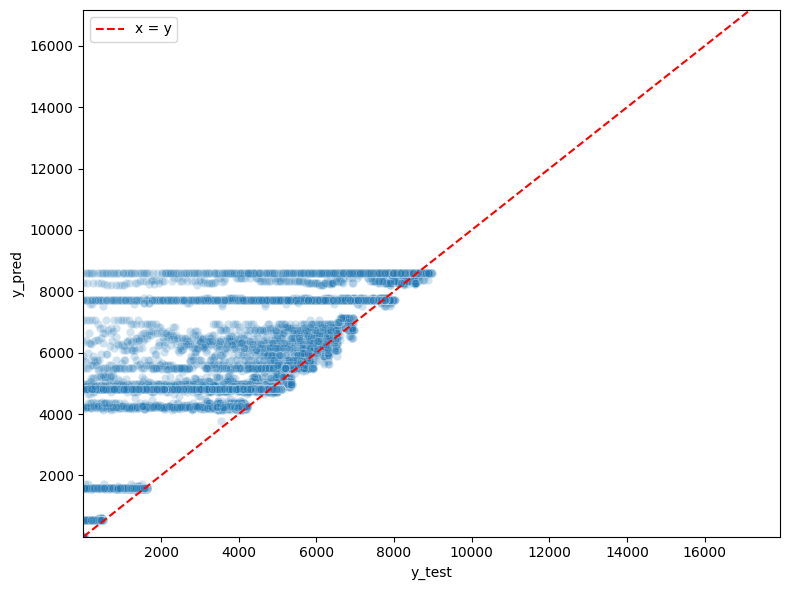

In [152]:
import seaborn as sns

import matplotlib.pyplot as plt

kde_df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}).sample(1_000_000)

plt.figure(figsize=(8, 6))
plt.plot([1, 1_000_000], [1, 1_000_000], color='red', linestyle='--', label='x = y')
sns.scatterplot(data=kde_df, x="y_test", y="y_pred", alpha=.2).set(xlim=(1, y_test.max() * 2), ylim=(1, y_pred.max() * 2))
#plt.xscale('log')
#plt.yscale('log')
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm
import lleaves



# Remove the model files
import os
try:
    os.remove(f"model_{objective_col}_{workload}_l2.txt")
except FileNotFoundError:
    pass
try:
    os.remove(f"model_{objective_col}_{workload}_l2.o")
except FileNotFoundError:
    pass

model.save_model(f"model_{objective_col}_{workload}_l2.txt")
llvm_model = lleaves.Model(model_file=f"model_{objective_col}_{workload}_l2.txt")
llvm_model.compile(cache=f"model_{objective_col}_{workload}_l2.o")

In [154]:
df_out['predicted_target'] = llvm_model.predict(df_out[features])

[Text(0.5, 1.0, 'Heatmap')]

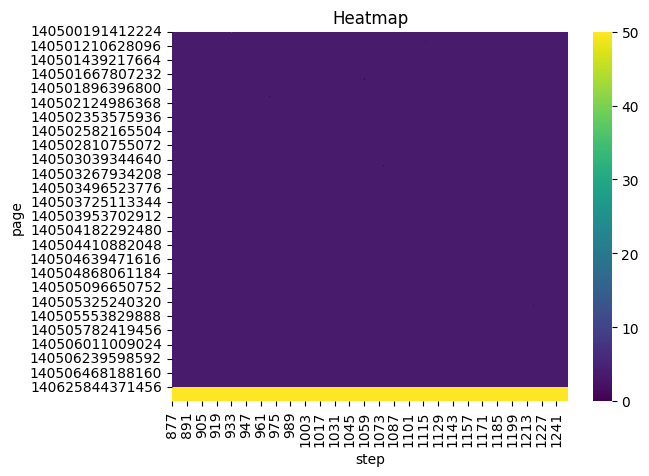

In [155]:
# Assuming the dataframe `df` has columns 'timestep', 'block', and 'count'
heatmap_data = df_out.pivot_table(index='page', columns='step', values='predicted_target')

# Plot the heatmap
sns.heatmap(heatmap_data.iloc[:, :], cmap="viridis", vmin=0, vmax=50).set(title="Heatmap")

[Text(0.5, 1.0, 'Heatmap')]

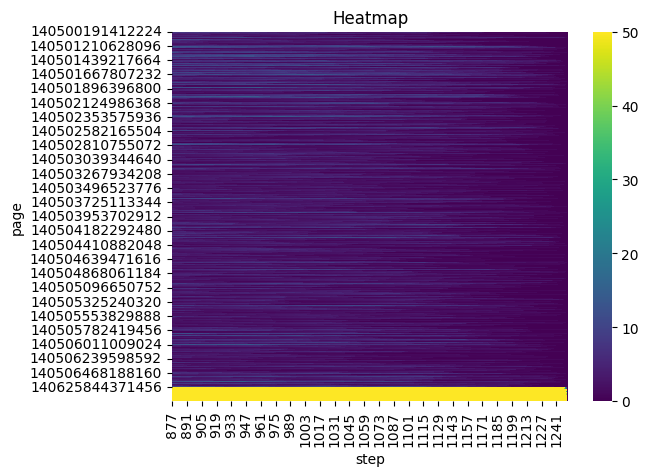

In [160]:
# Assuming the dataframe `df` has columns 'timestep', 'block', and 'count'
heatmap_data = df_out.pivot_table(index='page', columns='step', values=objective_col)

# Plot the heatmap
sns.heatmap(heatmap_data.iloc[:, :], cmap="viridis", vmax=50).set(title="Heatmap")

In [157]:
llvm_model.model_file

'model_discounted_reward_0.99_XSBench_1GB_l2.txt'

In [158]:
model.feature_name()

['ewma_2_perc',
 'ewma_5_perc',
 'ewma_20_perc',
 'ewma_100_perc',
 'group_-1_mean_perc',
 'group_1_mean_perc',
 'group_-2_mean_perc',
 'group_2_mean_perc',
 'group_-3_mean_perc',
 'group_3_mean_perc',
 'group_0_mean_perc',
 'age_count_total',
 'ewma_100_malloc_calls']

In [159]:
llvm_model.num_feature()

13